<a href="https://colab.research.google.com/github/rikesh28/Credit_Card_Fraud_Detection/blob/main/notebooks/3)%20preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
transaction_data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Raw Data/train_transaction.csv.zip')
identity_data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Raw Data/train_identity.csv.zip')

In [ ]:
# Merging data
df = transaction_data.merge(identity_data, on = 'TransactionID', how = 'left')
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


Features with missing values: 414

 =========TOP 20 FEATURES WITH MISSING DATA=========

      column  missing_count  missing_percentage
id_24  id_24         585793               99.20
id_21  id_21         585381               99.13
id_07  id_07         585385               99.13
id_25  id_25         585408               99.13
id_26  id_26         585377               99.13
id_08  id_08         585385               99.13
id_27  id_27         585371               99.12
id_23  id_23         585371               99.12
id_22  id_22         585371               99.12
dist2  dist2         552913               93.63
D7        D7         551623               93.41
id_18  id_18         545427               92.36
D13      D13         528588               89.51
D14      D14         528353               89.47
D12      D12         525823               89.04
id_04  id_04         524216               88.77
id_03  id_03         524216               88.77
D6        D6         517353               87.61

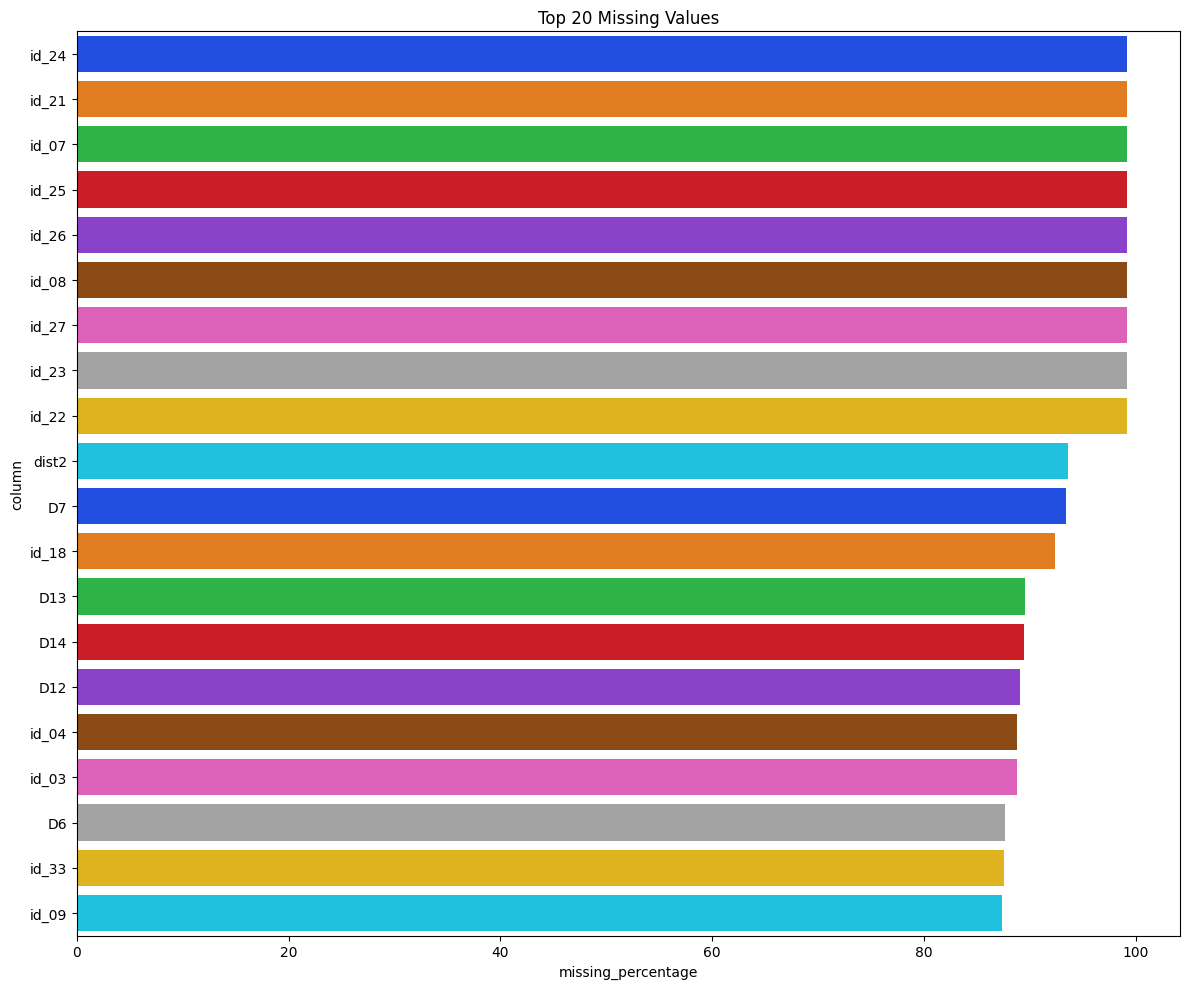

In [ ]:
# Missing value analysis
missing_stats = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values(by='missing_percentage', ascending=False)

missing_stats = missing_stats[missing_stats['missing_count'] > 0]

print(f'Features with missing values: {missing_stats.shape[0]}')
print(f'\n =========TOP 20 FEATURES WITH MISSING DATA=========')
print(f'\n{missing_stats.head(20)}')
print()

plt.figure(figsize = (12,10))
sns.barplot(data = missing_stats.head(20), x = 'missing_percentage', y = 'column', palette='bright')
plt.title('Top 20 Missing Values')
plt.tight_layout()
plt.show()

In [ ]:
df.isnull().sum()

,0
TransactionID,0
isFraud,0
TransactionDT,0
TransactionAmt,0
ProductCD,0
...,...
id_36,449555
id_37,449555
id_38,449555
DeviceType,449730


## Handling missing values

In [ ]:
# Strategy:
# - Drop features with >90% missing (not enough signal)
# - Categorical: fill with "Unknown"
# - Numerical: fill with -999 instead of mean/median.
#   Reason: for tree-based models, -999 acts as a distinct split point.
#   If missingness itself correlates with fraud (e.g. fraudsters skip optional fields),
#   the model can learn that. Mean imputation would destroy this signal.
#
# NOTE: fitting this on the full dataset before splitting is technically data leakage.
# In a real pipeline you'd fit imputation stats on training data only.
# For this project the impact is minimal since we're using constant fill values,
# but it's worth calling out.

high_missing_cols = missing_stats[missing_stats['missing_percentage'] > 90]['column'].tolist()
df_clean = df.drop(columns=high_missing_cols)

cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

if 'isFraud' in num_cols:
    num_cols.remove('isFraud')
if 'TransactionID' in num_cols:
    num_cols.remove('TransactionID')

print(f'Categorical: {len(cat_cols)}, Numerical: {len(num_cols)}')

for col in cat_cols:
    df_clean[col].fillna('Unknown', inplace=True)
for col in num_cols:
    df_clean[col].fillna(-999, inplace=True)

print(f'Remaining missing: {df_clean.isnull().sum().sum()}')
print(f'Shape: {df_clean.shape}')

## Feature engineering

Creating features based on what I found in the pattern analysis notebook.

In [ ]:
# Time features - fraud had clear hourly patterns in pattern analysis
df_clean['Transaction_hour'] = (df_clean['TransactionDT'] // 3600) % 24
df_clean['Transaction_day'] = (df_clean['TransactionDT'] // (3600 * 24))
df_clean['Transaction_day_of_week'] = df_clean['Transaction_day'] % 7
df_clean['is_business_hours'] = ((df_clean['Transaction_hour'] >= 9) & (df_clean['Transaction_hour'] <= 17)).astype(int)
df_clean['is_weekend'] = (df_clean['Transaction_day_of_week'].isin([5, 6])).astype(int)
df_clean['is_night'] = ((df_clean['Transaction_hour'] >= 23) | (df_clean['Transaction_hour'] <= 6)).astype(int)

print('Time features:')
for f in ['Transaction_hour', 'Transaction_day', 'Transaction_day_of_week',
          'is_business_hours', 'is_weekend', 'is_night']:
    print(f'  {f}')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

hourly_fraud = df_clean.groupby('Transaction_hour')['isFraud'].mean() * 100
axes[0].plot(hourly_fraud.index, hourly_fraud.values, marker='o')
axes[0].set_title('Hourly Fraud Rate')
axes[0].set_ylabel('Fraud Rate (%)')

for i, (feat, labels) in enumerate([
    ('is_business_hours', ['Off-hours', 'Business']),
    ('is_weekend', ['Weekday', 'Weekend']),
    ('is_night', ['Daytime', 'Night'])
]):
    vals = df_clean.groupby(feat)['isFraud'].mean() * 100
    axes[i+1].bar(range(len(vals)), vals.values)
    axes[i+1].set_title(f'Fraud Rate: {feat}')
    axes[i+1].set_xticklabels(labels)
    axes[i+1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

In [ ]:
# Amount features
df_clean['TransactionAmt_log'] = np.log1p(df_clean['TransactionAmt'])
df_clean['TransactionAmt_decimal'] = df_clean['TransactionAmt'] - df_clean['TransactionAmt'].astype(int)
df_clean['Transaction_bins'] = pd.cut(
    df_clean['TransactionAmt'],
    bins=[0, 50, 100, 200, 500, float('inf')],
    labels=['very_low', 'low', 'medium', 'high', 'very_high']
)
df_clean['is_round_amount'] = (df_clean['TransactionAmt'] % 10 == 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# log transform helps with the heavy right skew
for label, color in [(0, 'blue'), (1, 'red')]:
    sns.kdeplot(data=df_clean[df_clean['isFraud'] == label].sample(10000),
                x='TransactionAmt_log', label='Legit' if label == 0 else 'Fraud',
                ax=axes[0], fill=True, alpha=0.4)
axes[0].set_title('Log-Transformed Amount')
axes[0].legend()

# round amounts have slightly higher fraud rate
round_fraud = df_clean.groupby('is_round_amount')['isFraud'].mean() * 100
axes[1].bar(['Non-Round', 'Round'], round_fraud.values)
axes[1].set_title('Fraud Rate by Round Amount')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

In [ ]:
# Email features - based on pattern analysis showing email domain differences
df_clean['email_domain_match'] = (df_clean['P_emaildomain'] == df_clean['R_emaildomain']).astype(int)

common_providers = ['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com', 'aol.com']
df_clean['P_email_is_common'] = df_clean['P_emaildomain'].isin(common_providers).astype(int)
df_clean['R_email_is_common'] = df_clean['R_emaildomain'].isin(common_providers).astype(int)
df_clean['has_P_email'] = (df_clean['P_emaildomain'] != 'Unknown').astype(int)
df_clean['has_R_email'] = (df_clean['R_emaildomain'] != 'Unknown').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (feat, labels) in enumerate([
    ('email_domain_match', ['Different', 'Same']),
    ('P_email_is_common', ['Uncommon', 'Common']),
    ('has_P_email', ['Missing', 'Has Email'])
]):
    vals = df_clean.groupby(feat)['isFraud'].mean() * 100
    axes[i].bar(labels, vals.values)
    axes[i].set_title(f'Fraud Rate: {feat}')
    axes[i].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

## Encoding

Label encoding all categoricals. This is a simplification - label encoding imposes an
ordinal relationship that doesn't exist for features like card brand. Target encoding or
frequency encoding would be more principled, but label encoding works OK with tree-based
models since they can split on individual values.

In [ ]:
df_clean.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,is_night,TransactionAmt_log,TransactionAmt_decimal,Transaction_bins,is_round_amount,email_domain_match,P_email_is_common,R_email_is_common,has_P_email,has_R_email
0,2987000,0,86400,68.5,W,13926,-999.0,150.0,discover,142.0,...,1,4.241327,0.5,low,0,1,0,0,0,0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,1,3.401197,0.0,very_low,0,0,1,0,1,0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,1,4.094345,0.0,low,0,0,1,0,1,0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,1,3.931826,0.0,very_low,1,0,1,0,1,0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,1,3.931826,0.0,very_low,1,0,1,0,1,0


In [ ]:
# Same leakage caveat as missing value handling: fitting encoders on full data before split.
# For label encoding specifically this matters less (it's just mapping strings to ints),
# but in production you'd fit on training data only.
from sklearn.preprocessing import LabelEncoder

cat_features = df_clean.select_dtypes(include=['object']).columns.tolist()
cat_features.append('Transaction_bins')

if 'TransactionID' in cat_features:
    cat_features.remove('TransactionID')

print(f'Encoding {len(cat_features)} categorical features')

label_dict = {}
for col in cat_features:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_dict[col] = le

In [ ]:
df_clean.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,is_night,TransactionAmt_log,TransactionAmt_decimal,Transaction_bins,is_round_amount,email_domain_match,P_email_is_common,R_email_is_common,has_P_email,has_R_email
0,2987000,0,86400,68.5,4,13926,-999.0,150.0,2,142.0,...,1,4.241327,0.5,1,0,1,0,0,0,0
1,2987001,0,86401,29.0,4,2755,404.0,150.0,3,102.0,...,1,3.401197,0.0,4,0,0,1,0,1,0
2,2987002,0,86469,59.0,4,4663,490.0,150.0,4,166.0,...,1,4.094345,0.0,1,0,0,1,0,1,0
3,2987003,0,86499,50.0,4,18132,567.0,150.0,3,117.0,...,1,3.931826,0.0,4,1,0,1,0,1,0
4,2987004,0,86506,50.0,1,4497,514.0,150.0,3,102.0,...,1,3.931826,0.0,4,1,0,1,0,1,0


## Train/test split

Time-based split (not random) since this is fraud detection - we want to simulate
predicting future fraud using past data. Random split would leak future patterns.

In [ ]:
df_clean = df_clean.sort_values(by='TransactionDT').reset_index(drop=True)

split_index = int(len(df_clean) * 0.8)
train_df = df_clean[:split_index].copy()
test_df = df_clean[split_index:].copy()

print(f'Train: {train_df.shape}, fraud rate: {train_df["isFraud"].mean()*100:.2f}%')
print(f'Test:  {test_df.shape}, fraud rate: {test_df["isFraud"].mean()*100:.2f}%')

# fraud rates are similar across splits - good
features_to_drop = ['TransactionID', 'TransactionDT', 'isFraud']
X_train = train_df.drop(columns=features_to_drop, errors='ignore')
y_train = train_df['isFraud']
X_test = test_df.drop(columns=features_to_drop, errors='ignore')
y_test = test_df['isFraud']

print(f'\nX_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Total features: {X_train.shape[1]}')

In [ ]:
# Saving full cleaned Data
df_clean.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/df_clean.csv', index = False)

# Saving train/test splits
train_df.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/train_df.csv', index = False)
test_df.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/test_df.csv', index = False)

# Saving X and y - train and test
X_train.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/X_train.csv', index = False)
y_train.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/y_train.csv', index = False)

X_test.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/X_test.csv', index = False)
y_test.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/y_test.csv', index = False)

# Saving Feature names
feature_names = X_train.columns.tolist()
pd.DataFrame({'feature': feature_names}).to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/feature_names.csv', index = False)

print('All processed data saved.')

All processed data saved.


## What was done

- Dropped columns with >90% missing. Filled remaining: categoricals with "Unknown", numericals with -999.
- Engineered 15 features: 6 time-based, 4 amount-based, 5 email-based.
- Label encoded categoricals (acknowledged this is imperfect for nominal features).
- Time-based 80/20 split. 472K train, 118K test, ~3.5% fraud in both.
- Acknowledged data leakage from fitting encoders on full data (acceptable shortcut here, not for production).